# Tokenization in Natural Language Processing (NLP)

This notebook summarizes information contained in this open source resources:
- HuggingFace Tokenizers Documentation: https://huggingface.co/transformers/tokenizer_summary.html
- HuggingFace NLP Course: https://huggingface.co/learn/nlp-course/en/chapter2/4


## Tokenizers
Tokenizers are one of the core components of the NLP pipeline. They serve one purpose: to translate text into data that can be processed by the model. Models can only process numbers, so tokenizers need to convert our text inputs to numerical data. In this section, we’ll explore exactly what happens in the tokenization pipeline.

In NLP tasks, the data that is generally processed is raw text. Here’s an example of such text:

    Jim Henson was a puppeteer
However, models can only process numbers, so we need to find a way to convert the raw text to numbers. That’s what the tokenizers do, the goal is to find the most meaningful representation — that is, the one that makes the most sense to the model — and, if possible, the smallest representation.

Let’s take a look at some examples of tokenization algorithms, and try to answer some of the questions you may have about tokenization.

### Word-based
The first type of tokenizer that comes to mind is *word-based*. It’s generally very easy to set up and use with only a few rules, and it often yields decent results. For example, in the image below, the goal is to split the raw text into words and find a numerical representation for each of them:

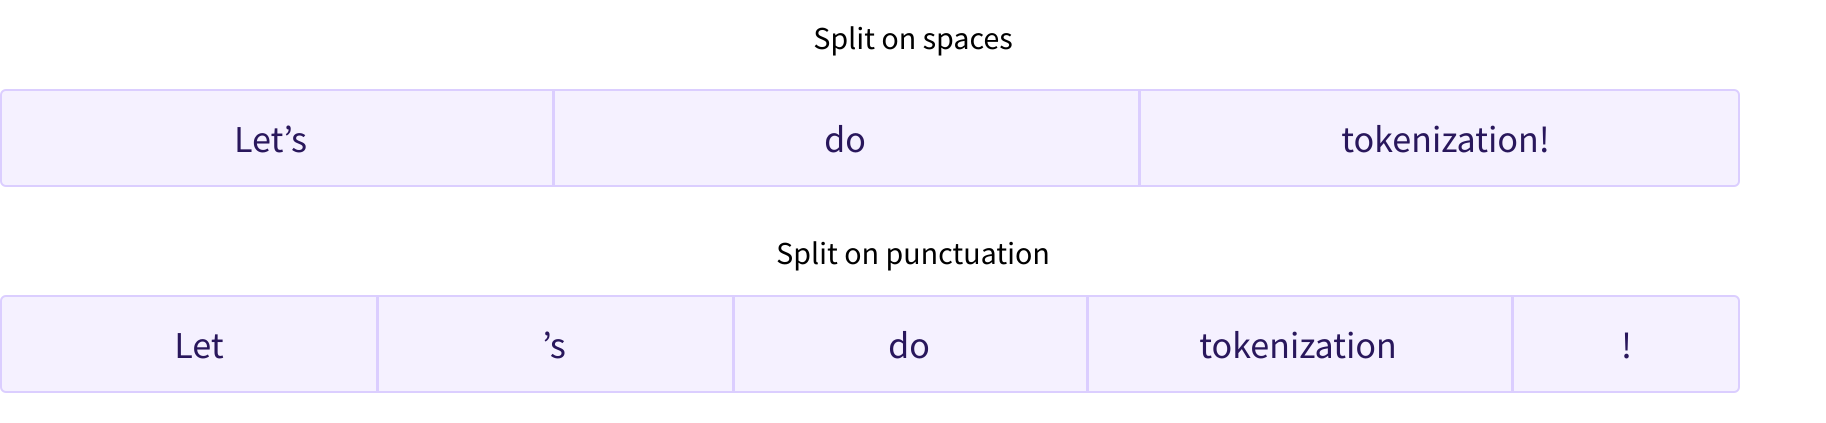

There are different ways to split the text. For example, we could use whitespace to tokenize the text into words by applying Python’s `split()` function:

    

In [ ]:
tokenized_text = "Jim Henson was a puppeteer".split()

print(tokenized_text)

['Jim', 'Henson', 'was', 'a', 'puppeteer']




There are also variations of word tokenizers that have extra rules for punctuation. With this kind of tokenizer, we can end up with some pretty large “vocabularies,” where a vocabulary is defined by the total number of independent tokens that we have in our corpus.

Each word gets assigned an ID, starting from 0 and going up to the size of the vocabulary. The model uses these IDs to identify each word.

If we want to completely cover a language with a word-based tokenizer, we’ll need to have an identifier for each word in the language, which will generate a huge amount of tokens. For example, there are over 500,000 words in the English language, so to build a map from each word to an input ID we’d need to keep track of that many IDs. Furthermore, words like “dog” are represented differently from words like “dogs”, and the model will initially have no way of knowing that “dog” and “dogs” are similar: it will identify the two words as unrelated. The same applies to other similar words, like “run” and “running”, which the model will not see as being similar initially.

Finally, we need a custom token to represent words that are not in our vocabulary. This is known as the “unknown” token, often represented as ”[UNK]” or ”<unk>”. It’s generally a bad sign if you see that the tokenizer is producing a lot of these tokens, as it wasn’t able to retrieve a sensible representation of a word and you’re losing information along the way. The goal when crafting the vocabulary is to do it in such a way that the tokenizer tokenizes as few words as possible into the unknown token.

One way to reduce the amount of unknown tokens is to go one level deeper, using a *character-based* tokenizer.

###  Character-based

Character-based tokenizers split the text into characters, rather than words. This has two primary benefits:

    

*   The vocabulary is much smaller.
*   There are much fewer out-of-vocabulary (unknown) tokens, since every word can be built from characters.
    

But here too some questions arise concerning spaces and punctuation:

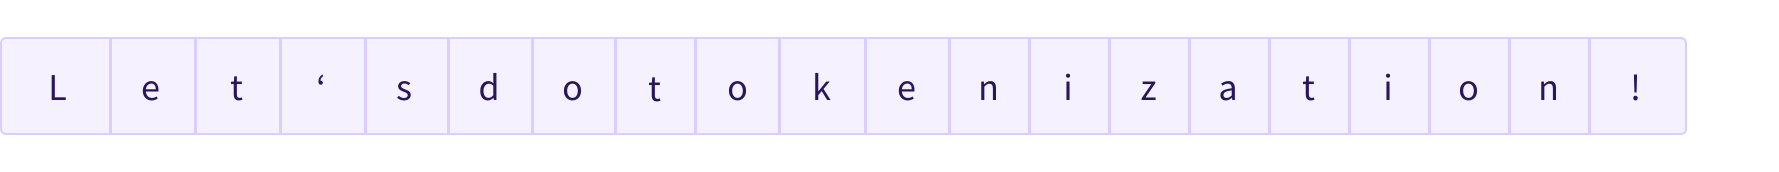
This approach isn’t perfect either. Since the representation is now based on characters rather than words, one could argue that, intuitively, it’s less meaningful: each character doesn’t mean a lot on its own, whereas that is the case with words. However, this again differs according to the language; in Chinese, for example, each character carries more information than a character in a Latin language.

Another thing to consider is that we’ll end up with a very large amount of tokens to be processed by our model: whereas a word would only be a single token with a word-based tokenizer, it can easily turn into 10 or more tokens when converted into characters.

To get the best of both worlds, we can use a third technique that combines the two approaches: *subword tokenization*.

 ### Subword tokenization

 Subword tokenization algorithms rely on the principle that frequently used words should not be split into smaller subwords, but rare words should be decomposed into meaningful subwords. It is particularly useful for handling out-of-vocabulary words and reducing the size of the vocabulary.

For instance, “annoyingly” might be considered a rare word and could be decomposed into “annoying” and “ly”. These are both likely to appear more frequently as standalone subwords, while at the same time the meaning of “annoyingly” is kept by the composite meaning of “annoying” and “ly”.

Here is an example showing how a subword tokenization algorithm would tokenize the sequence “Let’s do tokenization!“:

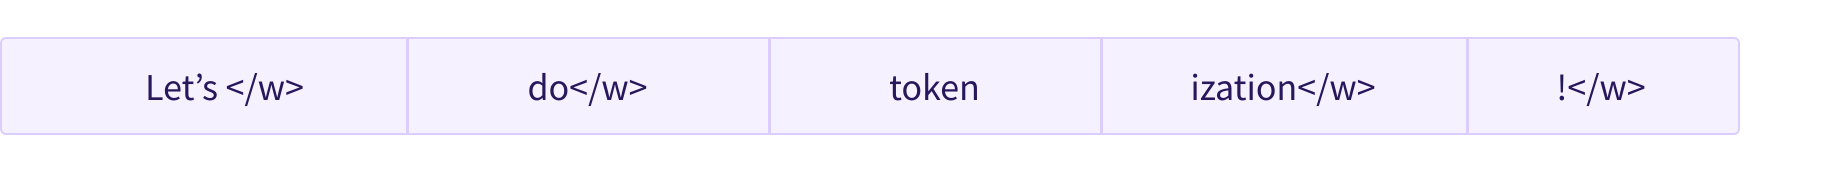

These subwords end up providing a lot of semantic meaning: for instance, in the example above “tokenization” was split into “token” and “ization”, two tokens that have a semantic meaning while being space-efficient (only two tokens are needed to represent a long word). This allows us to have relatively good coverage with small vocabularies, and close to no unknown tokens. This approach is especially useful in agglutinative languages such as Turkish, where you can form (almost) arbitrarily long complex words by stringing together subwords.

> Note: In the figure above, the </w> marker signifies the end of a word. So, for example, Let's</w> is treated as a single subword token ending at a word boundary, whereas "tokenization" is split into two subwords (token and ization</w>).

###  And more!
Unsurprisingly, there are many more techniques out there. To name a few:

*   WordPiece, as used in BERT (Google's Bidirectional Encoder Representations from Transformers, which had a huge impact in NLP in 2018)
*   Byte-level BPE, as used in GPT-2 (one of the key precursor models to ChatGPT, developed by OpenAI in 2019)
*   GPT-3.5 and GPT-4 (used in ChatGPT) use a modified version of byte-level BPE called "tiktoken"



## Understanding Tokenization with HuggingFace

HuggingFace's tokenizer library provides an excellent starting point for understanding how modern NLP models process text. The library offers easy-to-use implementations of various tokenization strategies, making it ideal for experimentation and learning. Through their high-performance implementations, we can quickly see how different models convert text into tokens that neural networks can process.

### BERT
BERT (Bidirectional Encoder Representations from Transformers) was introduced by Google in [2018](https://arxiv.org/abs/1810.04805) and represented a major breakthrough in NLP. Unlike previous models that processed text in one direction, BERT reads text *bidirectionally*, allowing it to understand context from both left and right. This bidirectional approach, combined with its pre-training on massive amounts of text, enabled BERT to achieve state-of-the-art results across many NLP tasks. BERT excels at comprehension tasks like text classification, named entity recognition, question answering, sentiment analysis, text similarity, and fill-in-the-blank prediction.

However, while BERT's bidirectional nature is powerful for understanding text, it makes the model unsuitable for text generation tasks (like those performed by ChatGPT) because generating text requires predicting one token at a time from left to right, which is incompatible with looking at future context.

### BERT tokenizer
We'll focus on BERT's tokenizer for our examples because:
- It uses WordPiece tokenization, which has a clear and intuitive approach
- It's widely used in many production systems
- The tokenization process is transparent and easy to understand
- It serves as a good foundation for understanding more complex tokenizers

### Loading and saving

Loading tokenizers with the `HuggingFace` library is straightforward using the `AutoTokenizer` class. This class is particularly convenient because it automatically detects and loads the correct type of tokenizer based on the model name you provide.

When we load a tokenizer, we want it to match the same vocabulary and rules that were used to train the original model. This is essential if we want to use the related model to process new text. Think of it like this: during training, BERT learned to understand text that was broken down in a specific way - we need to break down our text in exactly the same way for BERT to understand it properly. In the following code, `"bert-base-cased"` refers to the original version of BERT released by Google, which preserves the case of letters (uppercase/lowercase) in the text. When we use from_pretrained(), it downloads both the tokenization rules and vocabulary that were used to train this specific version of BERT.

In [ ]:
# First, we need to install the transformers library if it's not already installed.
!pip install -q transformers

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

We can now start using the tokenizer.

### Encoding

Translating text to numbers is known as *encoding*. Encoding is done in a two-step process: the tokenization, followed by the conversion to input IDs.

As we’ve seen, the first step is to split the text into words (or parts of words, punctuation symbols, etc..), usually called tokens. There are multiple rules that can govern that process, which is why we need to instantiate the tokenizer using the name of the model, to make sure we use the same rules that were used when the model was pretrained.

The second step is to convert those tokens into numbers, so we can build a tensor out of them and feed them to the model. To do this, the tokenizer has a vocabulary, which is the part we download when we instantiate it with the `from_pretrained()` method. Again, we need to use the same vocabulary used when the model was pretrained.

We will use some methods that perform parts of the tokenization pipeline separately to show the intermediate results of those steps, but in practice, you should call the tokenizer directly on your inputs (shown at the end).


### Tokenize the text into words or subwords

The tokenization process is done by the `tokenize()` method of the tokenizer:

In [ ]:
sequence = "Using a Transformer network is simple"
tokens = tokenizer.tokenize(sequence)

print(tokens)

['Using', 'a', 'Trans', '##former', 'network', 'is', 'simple']


As you can see, the BERT tokenizer is a subword tokenizer: it splits the words until it obtains tokens that can be represented by its vocabulary. That’s the case here with transformer, which is split into two tokens: *Trans* and *##former*.



### From tokens to input IDs (numerical representation)

The conversion to input IDs is handled by the `convert_tokens_to_ids()` tokenizer method:

In [ ]:
ids = tokenizer.convert_tokens_to_ids(tokens)

print("Input IDs: ", ids)

Input IDs:  [7993, 170, 13809, 23763, 2443, 1110, 3014]


These outputs, once converted to the appropriate framework tensor, can then be used as inputs to a model.

### All together

In practice, you'll rarely use `tokenize()` or `convert_tokens_to_ids()` separately. Instead, you can do everything in one step by calling the tokenizer directly on your input:

In [ ]:
tokenizer_output = tokenizer("Using a Transformer network is simple")
print(tokenizer_output["input_ids"])

[101, 7993, 170, 13809, 23763, 2443, 1110, 3014, 102]


This single call:
* Splits the text into tokens
* Converts tokens to IDs
* Adds special tokens ([CLS] = 101 at start, [SEP] = 102 at end, to specify the beginning and ending of the input sentence)

The actual output is a dictionary containing everything BERT needs to process your text. This is the format that BERT expects as input, which is why this is the most common way to use the tokenizer in real applications. The same goes for other models supported by `HuggingFace`.

# Decoding

*Decoding* is going the other way around: from vocabulary indices, we want to get a string. This can be done with the `decode()` method as follows:

In [ ]:
decoded_string = tokenizer.decode([7993, 170, 11303, 1200, 2443, 1110, 3014])
print("Decoded Text: ", decoded_string)

Decoded Text:  Using a transformer network is simple


Note that the decode method not only converts the indices back to tokens, but also groups together the tokens that were part of the same words to produce a readable sentence. This behavior will be extremely useful when we use models that predict new text (either text generated from a prompt, or for sequence-to-sequence problems like translation or summarization).
<!--
By now you should understand the atomic operations a tokenizer can handle: tokenization, conversion to IDs, and converting IDs back to a string. However, we’ve just scraped the tip of the iceberg. In the following section, we’ll take our approach to its limits and take a look at how to overcome them. -->

# Example with a different text

In [ ]:
subword_text = "Tokenization is a crucial step in NLP."
subword_tokens = tokenizer.tokenize(subword_text)
print("Subword Tokens:", subword_tokens)

subword_ids = tokenizer.convert_tokens_to_ids(subword_tokens)
print("Subword IDs:", subword_ids)

subword_decoded_text = tokenizer.decode(subword_ids)
print("Subword Decoded Text:", subword_decoded_text)

Subword Tokens: ['To', '##ken', '##ization', 'is', 'a', 'crucial', 'step', 'in', 'NL', '##P', '.']
Subword IDs: [1706, 6378, 2734, 1110, 170, 10268, 2585, 1107, 21239, 2101, 119]
Subword Decoded Text: Tokenization is a crucial step in NLP.
